In [43]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

**Task 1: Dataset Exploration**

In [44]:
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

df = pd.DataFrame(X, columns=feature_names)
df["target"] = y
df["species"] = df["target"].apply(lambda i: target_names[i])

print(f"Number of samples : {X.shape[0]}")
print(f"Number of features: {X.shape[1]}")
print(f"Feature names      : {feature_names}")
print(f"Target classes      : {list(target_names)}")

Number of samples : 150
Number of features: 4
Feature names      : ['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']
Target classes      : [np.str_('setosa'), np.str_('versicolor'), np.str_('virginica')]


The dataset contains of 150 rows and 4 columns, and is about iris dataset which contains 3 type of species that are setosa, versicolor and virginica.

In [45]:
print("First five records:")
df.head()

First five records:


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target,species
0,5.1,3.5,1.4,0.2,0,setosa
1,4.9,3.0,1.4,0.2,0,setosa
2,4.7,3.2,1.3,0.2,0,setosa
3,4.6,3.1,1.5,0.2,0,setosa
4,5.0,3.6,1.4,0.2,0,setosa


Displaying first 5  rows from the dataset.

In [46]:
print("Class distribution:")
df["species"].value_counts()

Class distribution:


,count
species,
setosa,50
versicolor,50
virginica,50


All the three  type of species are equally distributed with each species containing 50 samples.

**Task 2: Data Preparation**

In [47]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples : {X_test.shape[0]}")

Training samples: 120
Testing samples : 30


Split into 80% training / 20% testing using `random_state=42`.
The model is trained on the training set so it can learn patterns, and evaluated on a separate, unseen testing set to estimate how well it generalizes to new data. Evaluating on the same data used for training would give an overly optimistic score and hide overfitting.

**Task 3: Building a Decision Tree Classifier (default parameters)**

In [48]:
clf_default = DecisionTreeClassifier(random_state=42)
clf_default.fit(X_train, y_train)
y_pred = clf_default.predict(X_test)

acc_default = accuracy_score(y_test, y_pred)
print(f"Accuracy: {acc_default:.4f}")

Accuracy: 0.9333


The accuracy of decision tree on this dataset achieves 93.33% accuracy.

In [49]:
print("Confusion Matrix:")
print(confusion_matrix(y_test, y_pred))

Confusion Matrix:
[[10  0  0]
 [ 0  9  1]
 [ 0  1  9]]


In [50]:
print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=target_names))

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30



**Task 4: Visualizing the Decision Tree**

Training Accuracy: 0.9833
Testing Accuracy: 0.9667
Tree Depth: 3
Leaf Nodes: 4


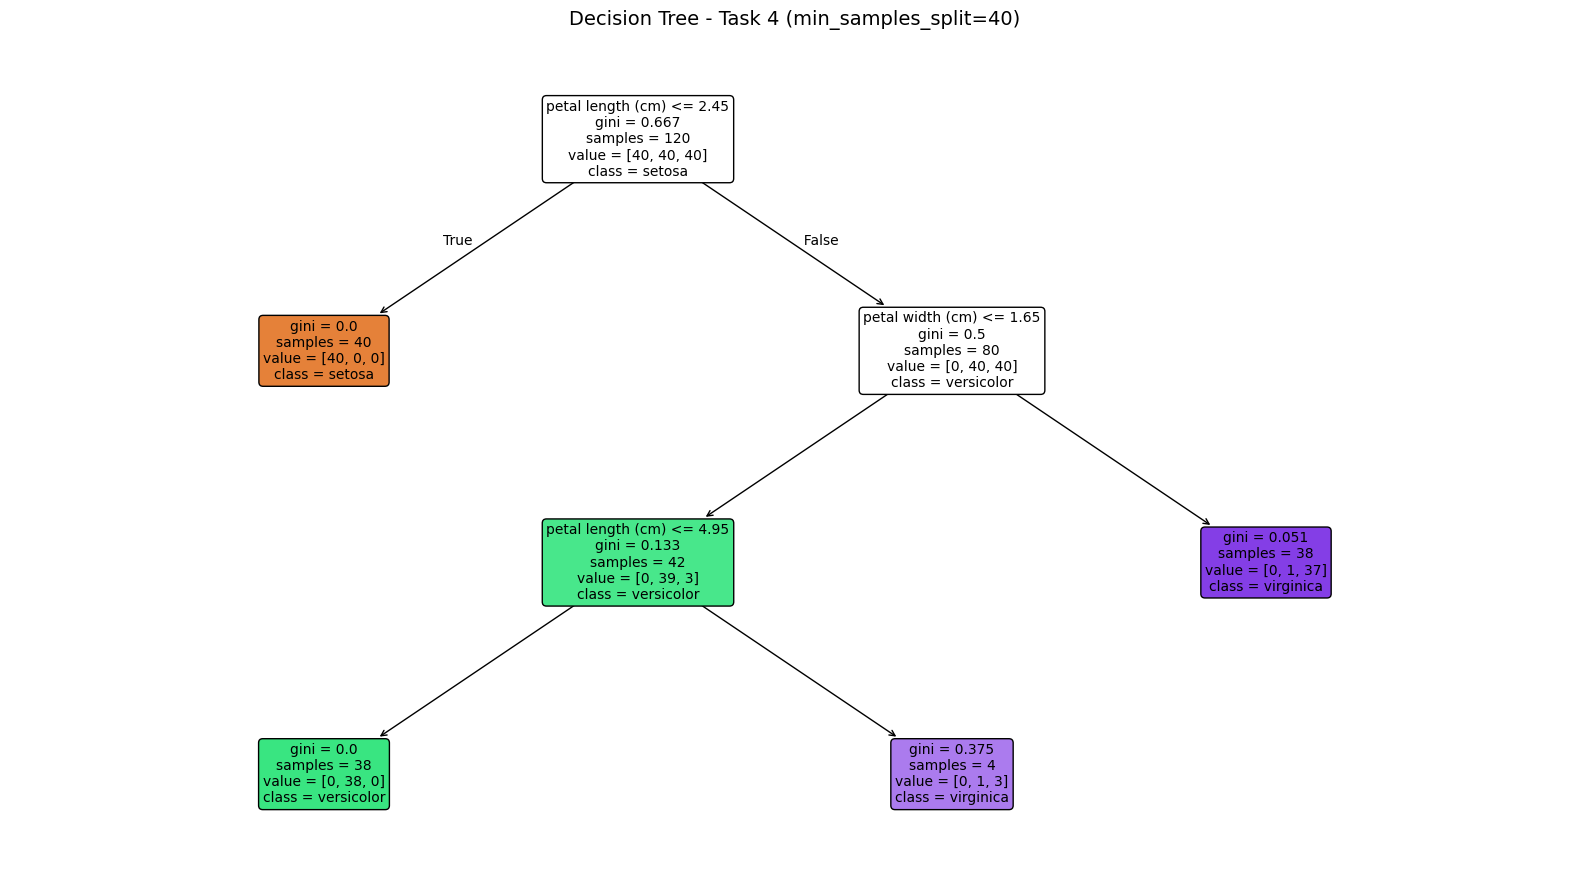

In [51]:
RANDOM_STATE = 42
iris = load_iris()
X = iris.data
y = iris.target
feature_names = iris.feature_names
target_names = iris.target_names

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

clf = DecisionTreeClassifier(min_samples_split=40, random_state=RANDOM_STATE)
clf.fit(X_train, y_train)

train_acc = accuracy_score(y_train, clf.predict(X_train))
test_acc = accuracy_score(y_test, clf.predict(X_test))
print(f"Training Accuracy: {train_acc:.4f}")
print(f"Testing Accuracy: {test_acc:.4f}")
print(f"Tree Depth: {clf.get_depth()}")
print(f"Leaf Nodes: {clf.get_n_leaves()}")

plt.figure(figsize=(16, 9))
plot_tree(
    clf,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    rounded=True,
    fontsize=10,
)
plt.title("Decision Tree - Task 4 (min_samples_split=40)", fontsize=14)
plt.tight_layout()
plt.show()

In [52]:
tree_ = clf_default.tree_
root_feature = feature_names[tree_.feature[0]]
root_threshold = tree_.threshold[0]
n_leaves = clf_default.get_n_leaves()
max_depth_actual = clf_default.get_depth()
n_internal = tree_.node_count - n_leaves

print(f"Root node splits on: '{root_feature}' <= {root_threshold:.2f}")
print(f"Number of internal (split) nodes: {n_internal}")
print(f"Number of leaf nodes: {n_leaves}")
print(f"Maximum depth of the tree: {max_depth_actual}")

Root node splits on: 'petal length (cm)' <= 2.45
Number of internal (split) nodes: 7
Number of leaf nodes: 8
Maximum depth of the tree: 5


The Decision Tree (using Gini impurity by default) evaluates every feature/threshold combination and picks the split that produces the greatest reduction in impurity across the child nodes. The root feature above gives the purest separation of the three Iris classes in a single split that's why it's chosen first, ahead of any other feature.

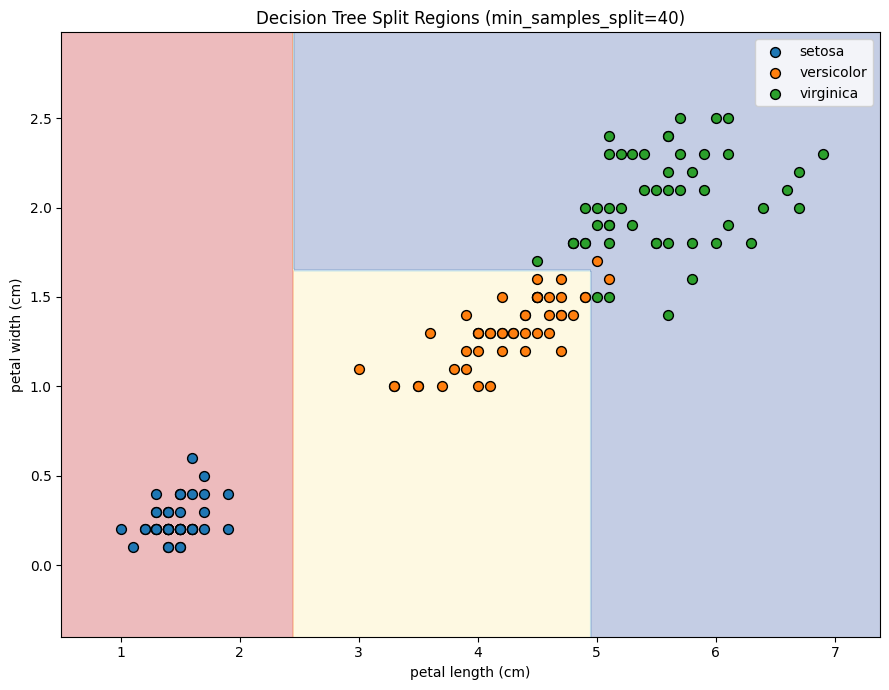


2D-feature tree depth: 3, leaves: 4


In [53]:
feat_idx = [2, 3]
X2_train = X_train[:, feat_idx]

clf_2d = DecisionTreeClassifier(min_samples_split=40, random_state=RANDOM_STATE)
clf_2d.fit(X2_train, y_train)

x_min, x_max = X[:, feat_idx[0]].min() - 0.5, X[:, feat_idx[0]].max() + 0.5
y_min, y_max = X[:, feat_idx[1]].min() - 0.5, X[:, feat_idx[1]].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02), np.arange(y_min, y_max, 0.02))
Z = clf_2d.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)

plt.figure(figsize=(9, 7))
plt.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]
for i, name in enumerate(target_names):
    idx = y == i
    plt.scatter(X[idx, feat_idx[0]], X[idx, feat_idx[1]], label=name, edgecolor="k", s=50, color=colors[i])
plt.xlabel(feature_names[feat_idx[0]])
plt.ylabel(feature_names[feat_idx[1]])
plt.title("Decision Tree Split Regions (min_samples_split=40)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"\n2D-feature tree depth: {clf_2d.get_depth()}, leaves: {clf_2d.get_n_leaves()}")

**Task 5: Comparing Gini Index and Entropy**

In [54]:
clf_gini = DecisionTreeClassifier(criterion="gini", random_state=42)
clf_gini.fit(X_train, y_train)
acc_gini = accuracy_score(y_test, clf_gini.predict(X_test))

clf_entropy = DecisionTreeClassifier(criterion="entropy", random_state=42)
clf_entropy.fit(X_train, y_train)
acc_entropy = accuracy_score(y_test, clf_entropy.predict(X_test))

task5_table = pd.DataFrame({
    "Criterion": ["gini", "entropy"],
    "Accuracy": [acc_gini, acc_entropy],
    "Tree Depth": [clf_gini.get_depth(), clf_entropy.get_depth()],
    "Leaf Nodes": [clf_gini.get_n_leaves(), clf_entropy.get_n_leaves()],
    "Root Feature": [
        feature_names[clf_gini.tree_.feature[0]],
        feature_names[clf_entropy.tree_.feature[0]],
    ],
})
task5_table

,Criterion,Accuracy,Tree Depth,Leaf Nodes,Root Feature
0,gini,0.933333,5,8,petal length (cm)
1,entropy,0.933333,5,8,petal length (cm)


Since both criteria give the same performance, either can be used for this dataset. In general, Gini is often preferred for its slightly faster computation (no logarithm involved), while Entropy is sometimes preferred when a more information-theoretic interpretation is desired. For Iris specifically, the choice makes no practical difference.

----- Gini Decision Tree -----
Testing Accuracy : 0.9667
Tree Depth       : 3
Leaf Nodes       : 4


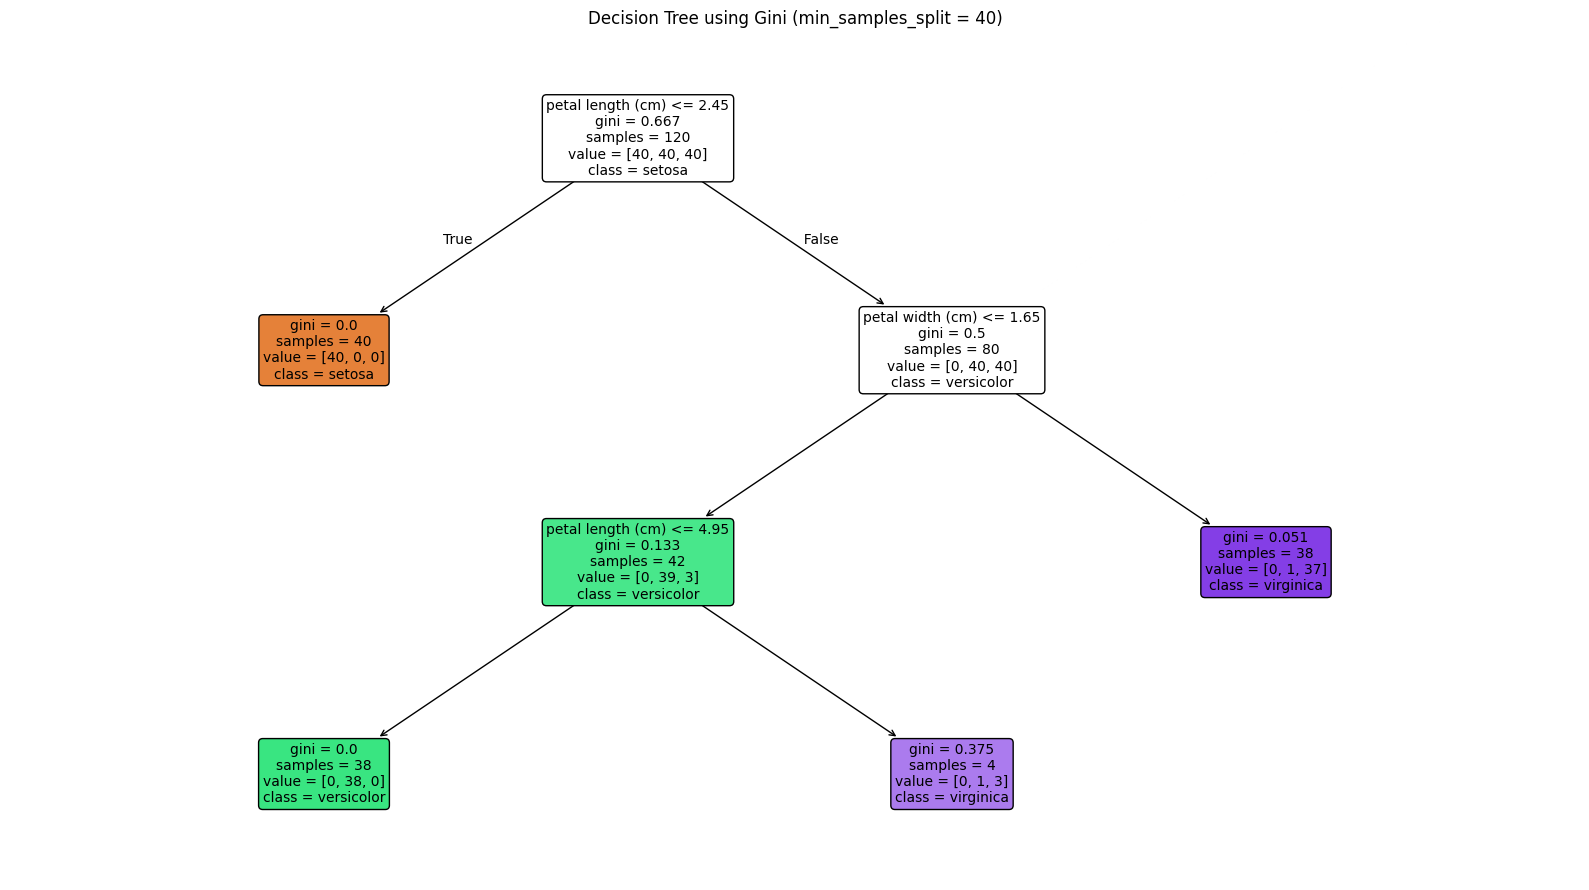

In [55]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

clf_gini = DecisionTreeClassifier(
    criterion="gini",
    min_samples_split=40,
    random_state=RANDOM_STATE
)

clf_gini.fit(X_train, y_train)

gini_pred = clf_gini.predict(X_test)

print("----- Gini Decision Tree -----")
print(f"Testing Accuracy : {accuracy_score(y_test, gini_pred):.4f}")
print(f"Tree Depth       : {clf_gini.get_depth()}")
print(f"Leaf Nodes       : {clf_gini.get_n_leaves()}")

plt.figure(figsize=(16,9))
plot_tree(
    clf_gini,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree using Gini (min_samples_split = 40)")
plt.tight_layout()
plt.show()

----- Entropy Decision Tree -----
Testing Accuracy : 0.9667
Tree Depth       : 3
Leaf Nodes       : 4


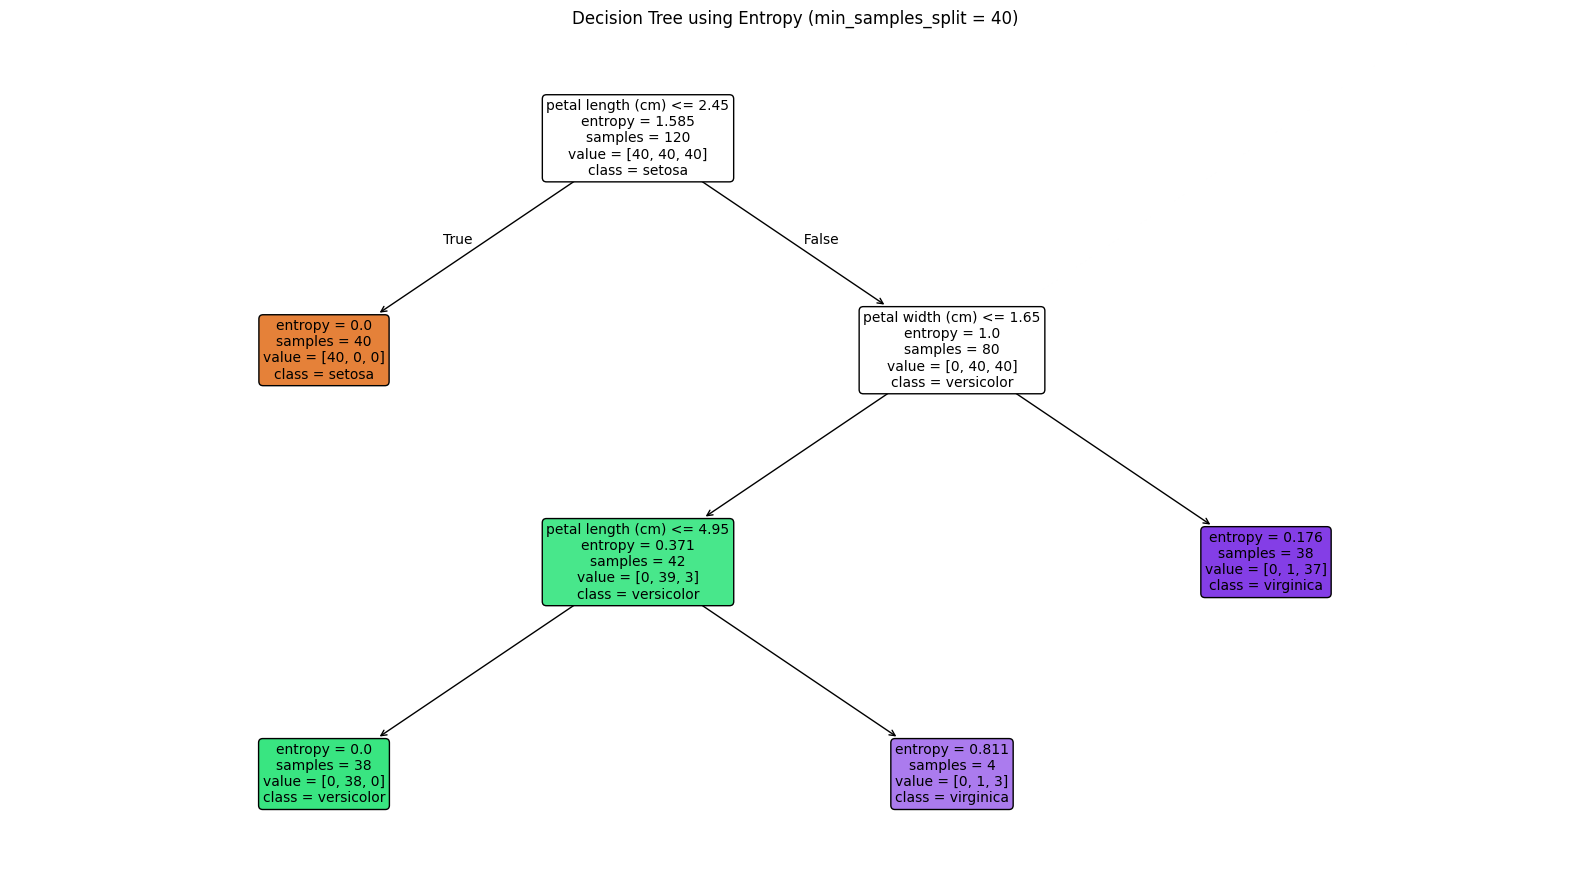

In [56]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score
import matplotlib.pyplot as plt

clf_entropy = DecisionTreeClassifier(
    criterion="entropy",
    min_samples_split=40,
    random_state=RANDOM_STATE
)

clf_entropy.fit(X_train, y_train)

entropy_pred = clf_entropy.predict(X_test)

print("----- Entropy Decision Tree -----")
print(f"Testing Accuracy : {accuracy_score(y_test, entropy_pred):.4f}")
print(f"Tree Depth       : {clf_entropy.get_depth()}")
print(f"Leaf Nodes       : {clf_entropy.get_n_leaves()}")

plt.figure(figsize=(16,9))
plot_tree(
    clf_entropy,
    feature_names=feature_names,
    class_names=target_names,
    filled=True,
    rounded=True,
    fontsize=10
)
plt.title("Decision Tree using Entropy (min_samples_split = 40)")
plt.tight_layout()
plt.show()

**Task 6: Effect of Maximum Tree Depth**

In [58]:
depth_values = [1, 2, 3, 4, None]
task6_rows = []
for d in depth_values:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    clf.fit(X_train, y_train)
    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    task6_rows.append({
        "Max Depth": d if d is not None else "None",
        "Training Accuracy": round(train_acc, 4),
        "Testing Accuracy": round(test_acc, 4),
        "Tree Depth": clf.get_depth(),
    })
task6_table = pd.DataFrame(task6_rows)
task6_table

,Max Depth,Training Accuracy,Testing Accuracy,Tree Depth
0,1,0.6667,0.6667,1
1,2,0.9667,0.9333,2
2,3,0.9833,0.9667,3
3,4,0.9917,0.9333,4
4,None,1.0000,0.9333,5


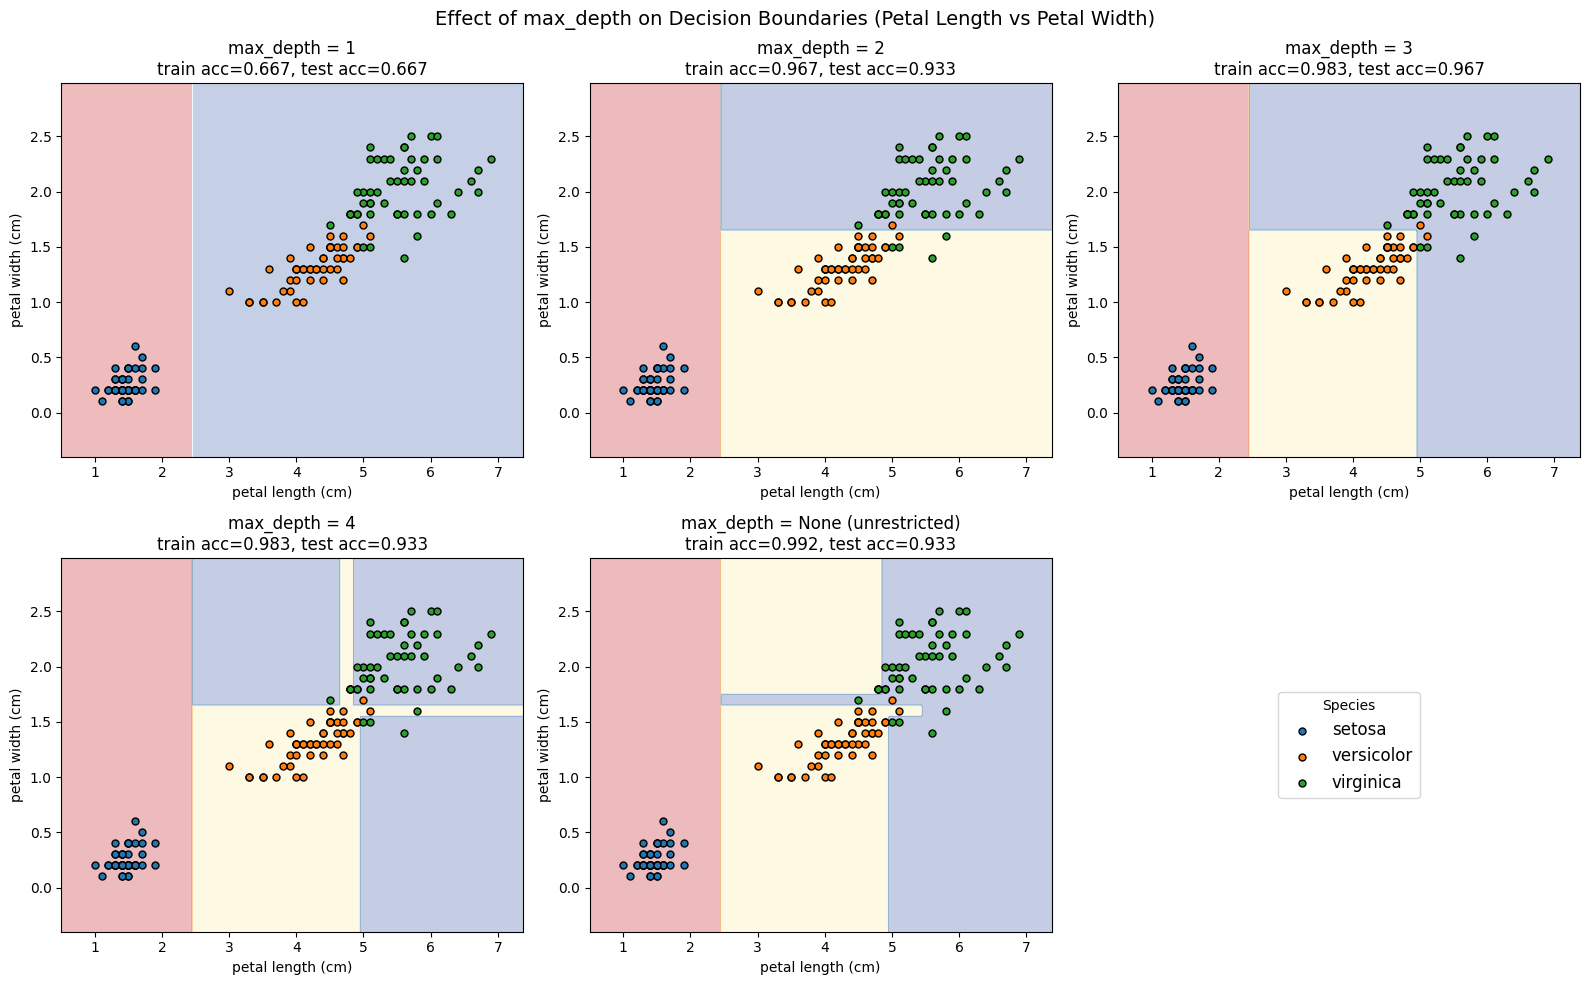

In [59]:
RANDOM_STATE = 42
iris = load_iris()
feature_names = iris.feature_names
target_names = iris.target_names

X = iris.data[:, [2, 3]]
y = iris.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)

depth_values = [1, 2, 3, 4, None]

x_min, x_max = X[:, 0].min() - 0.5, X[:, 0].max() + 0.5
y_min, y_max = X[:, 1].min() - 0.5, X[:, 1].max() + 0.5
xx, yy = np.meshgrid(np.arange(x_min, x_max, 0.02),
                      np.arange(y_min, y_max, 0.02))

fig, axes = plt.subplots(2, 3, figsize=(16, 10))
axes = axes.ravel()
colors = ["#1f77b4", "#ff7f0e", "#2ca02c"]

task6_rows = []
for i, d in enumerate(depth_values):
    clf = DecisionTreeClassifier(max_depth=d, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)

    train_acc = accuracy_score(y_train, clf.predict(X_train))
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    task6_rows.append({
        "Max Depth": d if d is not None else "None",
        "Training Accuracy": round(train_acc, 4),
        "Testing Accuracy": round(test_acc, 4),
        "Tree Depth": clf.get_depth(),
    })

    Z = clf.predict(np.c_[xx.ravel(), yy.ravel()]).reshape(xx.shape)
    ax = axes[i]
    ax.contourf(xx, yy, Z, alpha=0.3, cmap=plt.cm.RdYlBu)
    for c, name in enumerate(target_names):
        idx = y == c
        ax.scatter(X[idx, 0], X[idx, 1], label=name, edgecolor="k", s=25, color=colors[c])

    depth_label = "None (unrestricted)" if d is None else d
    ax.set_title(f"max_depth = {depth_label}\ntrain acc={train_acc:.3f}, test acc={test_acc:.3f}")
    ax.set_xlabel(feature_names[2])
    ax.set_ylabel(feature_names[3])

axes[-1].axis("off")
handles, labels = axes[0].get_legend_handles_labels()
axes[-1].legend(handles, labels, loc="center", fontsize=12, title="Species")

plt.suptitle("Effect of max_depth on Decision Boundaries (Petal Length vs Petal Width)", fontsize=14)
plt.tight_layout()
plt.show()
plt.close()

In [60]:
task6_table = pd.DataFrame(task6_rows)
print(task6_table.to_string(index=False))

Max Depth  Training Accuracy  Testing Accuracy  Tree Depth
        1             0.6667            0.6667           1
        2             0.9667            0.9333           2
        3             0.9833            0.9667           3
        4             0.9833            0.9333           4
     None             0.9917            0.9333           5


**Which model is underfitting?** `max_depth=1` — it can't separate versicolor from virginica at all, giving the lowest accuracy on both train and test sets.

**Which model gives the best generalization?** `max_depth=3` typically has the highest testing accuracy while training accuracy stays close to it (small train/test gap).

**Which model is likely to overfit?** `max_depth=None` (unrestricted) — training accuracy hits (or nears) a perfect 1.0000 while testing accuracy plateaus lower, meaning the tree has grown deep enough to fit noise/outliers in the training data.

**Task 7: Effect of min_samples_split**

In [61]:
split_values = [2, 5, 10, 20]
task7_rows = []
for s in split_values:
    clf = DecisionTreeClassifier(min_samples_split=s, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    task7_rows.append({
        "min_samples_split": s,
        "Accuracy": round(test_acc, 4),
        "Tree Depth": clf.get_depth(),
        "Leaf Nodes": clf.get_n_leaves(),
    })
task7_table = pd.DataFrame(task7_rows)
task7_table

,min_samples_split,Accuracy,Tree Depth,Leaf Nodes
0,2,0.9333,5,8
1,5,0.9667,3,5
2,10,0.9667,3,5
3,20,0.9667,3,5


Increasing `min_samples_split` forces a node to have more samples before it's even considered for splitting, pruning away splits on small, less-reliable subsets. This produces shallower, simpler trees with fewer leaves.

**Task 8: Effect of min_samples_leaf**

In [62]:
leaf_values = [1, 2, 5, 10]
task8_rows = []
for l in leaf_values:
    clf = DecisionTreeClassifier(min_samples_leaf=l, random_state=RANDOM_STATE)
    clf.fit(X_train, y_train)
    test_acc = accuracy_score(y_test, clf.predict(X_test))
    task8_rows.append({
        "min_samples_leaf": l,
        "Accuracy": round(test_acc, 4),
        "Tree Depth": clf.get_depth(),
        "Leaf Nodes": clf.get_n_leaves(),
    })
task8_table = pd.DataFrame(task8_rows)
task8_table

,min_samples_leaf,Accuracy,Tree Depth,Leaf Nodes
0,1,0.9333,5,8
1,2,0.9667,4,6
2,5,0.9333,3,5
3,10,0.9333,3,5


`min_samples_leaf` sets a floor on how few samples a leaf can represent. Small values (like 1) let the tree carve out tiny, highly specific leaves essentially memorizing individual training points, a direct form of overfitting. Larger values force each leaf to summarize a bigger group of samples, smoothing over noise at the cost of some flexibility.

**Task 9: Hyperparameter Tuning with GridSearchCV**

In [63]:
param_grid = {
    "criterion": ["gini", "entropy"],
    "max_depth": [2, 3, 4, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
}

grid_search = GridSearchCV(
    DecisionTreeClassifier(random_state=RANDOM_STATE),
    param_grid,
    cv=5,
    scoring="accuracy",
    n_jobs=-1,
)
grid_search.fit(X_train, y_train)

best_model = grid_search.best_estimator_
test_acc_best = accuracy_score(y_test, best_model.predict(X_test))

print(f"Best hyperparameters: {grid_search.best_params_}")
print(f"Best CV score (train): {grid_search.best_score_:.4f}")
print(f"Test accuracy (tuned): {test_acc_best:.4f}")
print(f"Test accuracy (default): {acc_default:.4f}")

Best hyperparameters: {'criterion': 'gini', 'max_depth': 4, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV score (train): 0.9500
Test accuracy (tuned): 0.9333
Test accuracy (default): 0.9333


GridSearchCV found the best parameters (gini, max_depth=4, min_samples_leaf=1, min_samples_split=2) with a CV score of 95%, but test accuracy remained the same (93.33%) as the default model. This shows that hyperparameter tuning didn't improve generalization here, likely because the Iris dataset is simple and the default model was already near-optimal.

**Task 10: Analysis**

**1. Role of the `criterion` parameter**
`criterion` determines the impurity measure used to score candidate splits `gini` (Gini impurity: probability of misclassifying a randomly chosen sample) or `entropy` (information gain, based on Shannon entropy). Both measure "how mixed" the classes are in a node; the tree picks whichever split most reduces this mixedness.

**2. How `max_depth` influences underfitting/overfitting**
A very shallow tree can't capture the decision boundaries needed to separate all classes which lead to underfitting. As depth increases, train accuracy climbs toward 100%, but past a certain point extra depth mainly fits noise specific to the training set which lead to overfitting (training accuracy keeps rising while test accuracy plateaus or drops).

**3. Why larger `min_samples_split` / `min_samples_leaf` produce simpler trees**
Both set a minimum population requirement before more structure is allowed raising either threshold blocks splits/leaves that would carve out very small, specific subgroups, so the tree stops earlier with fewer, larger leaves.

**4. Which hyperparameter had the greatest impact?**
Compare the accuracy spread across Task 6 (max_depth) against Tasks 7–8 (min_samples_split / min_samples_leaf) in the tables above max_depth typically shows the widest swing since it directly controls the tree's fundamental capacity, while the min_samples parameters act more gently by pruning marginal splits.

**5. Recommended model for Iris**
Based on the Task 6 results, a Decision Tree with **`max_depth=3`** (default criterion=gini) typically offers the best balance: near-peak testing accuracy with training accuracy close behind (small train/test gap = good generalization, not overfitting), while staying simple and interpretable. Three splits is enough structure to separate all three Iris species; extra depth mainly adds complexity without real benefit.